
# Threshold Validation

Notebook ini digunakan untuk pemilihan threshold.

## Tujuan

1. Memuat tiga **frozen models**:
   - AE–MLP;
   - standard MLP;
   - LightGBM.
2. Memilih threshold **hanya dari validation set**.
3. Mengeluarkan `Infiltration` dari threshold selection agar tetap menjadi held-out zero-day class.
4. Membekukan threshold sebelum test set dimuat untuk evaluasi.
5. Mengevaluasi test set satu kali menggunakan threshold yang telah dibekukan.
6. Menghasilkan:
   - threshold selection evidence;
   - binary metrics;
   - confusion matrix;
   - per-class detection rate;
   - held-out Infiltration detection rate;
   - PR-AUC dan ROC-AUC;
   - file threshold final;
   - CSV dan ZIP bukti eksperimen.

## Aturan threshold

Threshold dipilih dari grid tetap `0.01–0.99` dengan interval `0.01`.

Kriteria:

1. `FPR validation ≤ 2%`;
2. dari kandidat yang memenuhi batas tersebut, pilih F1 attack tertinggi;
3. jika terjadi nilai F1 sama, pilih FPR lebih rendah;
4. jika masih sama, pilih threshold lebih tinggi.

## Batas interpretasi

- Model weights, scaler, dataset split, dan preprocessing tidak diubah.
- Tidak ada retraining, refitting, atau threshold tuning pada test set.
- PR-AUC dan ROC-AUC dihitung dari probabilitas dan tidak bergantung pada threshold.
- Seluruh binary metrics dan per-class detection rate pada test menggunakan threshold validation yang telah dibekukan.



## Catatan versi grid 0.01

Notebook ini menjadi candidate threshold grid diganti menjadi:

```python
np.arange(0.01, 1.00, 0.01)
```

```text
/content/drive/MyDrive/CICIDS2018/threshold_validation_final_grid_0p01/
```


In [5]:

# ============================================================
# CELL 1 — CPU-ONLY SETUP DAN ENVIRONMENT
# ============================================================

import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

CPU_THREADS = 2
for variable in [
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "NUMEXPR_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "TF_NUM_INTRAOP_THREADS",
]:
    os.environ[variable] = str(CPU_THREADS)
os.environ["TF_NUM_INTEROP_THREADS"] = "1"

from google.colab import drive
drive.mount("/content/drive")

import gc
import json
import pickle
import shutil
import zipfile
import platform
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

import tensorflow as tf
import lightgbm
import sklearn

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    precision_recall_curve,
    roc_auc_score,
    auc,
)

try:
    tf.config.set_visible_devices([], "GPU")
except RuntimeError as exc:
    print("GPU configuration warning:", exc)

try:
    tf.config.threading.set_intra_op_parallelism_threads(CPU_THREADS)
    tf.config.threading.set_inter_op_parallelism_threads(1)
except RuntimeError as exc:
    print("TensorFlow threading warning:", exc)

np.random.seed(42)
tf.random.set_seed(42)

print("Python        :", platform.python_version())
print("TensorFlow    :", tf.__version__)
print("LightGBM      :", lightgbm.__version__)
print("scikit-learn :", sklearn.__version__)
print("CPU threads   :", CPU_THREADS)
print("RAM           :", round(psutil.virtual_memory().total / (1024**3), 2), "GB")
print("GPU visible   :", tf.config.list_physical_devices("GPU"))

assert tf.config.list_physical_devices("GPU") == []
print("\nEnvironment verified.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Python        : 3.12.13
TensorFlow    : 2.20.0
LightGBM      : 4.6.0
scikit-learn : 1.6.1
CPU threads   : 2
RAM           : 12.67 GB
GPU visible   : []

Environment verified.


In [6]:

# ============================================================
# CELL 2 — PATH, EXTRACT MODEL, DAN VALIDASI ARTIFACT
# ============================================================

BASE_DIR = Path("/content/drive/MyDrive/CICIDS2018")

ZIP_AE   = BASE_DIR / "model_AE_MLP (1).zip"
ZIP_MLP  = BASE_DIR / "model_MLP (1).zip"
ZIP_LGBM = BASE_DIR / "model_LightGBM (1).zip"

DATASET_CANDIDATES = [
    BASE_DIR / "dataset_splitt.joblib",
]

WORK_DIR = Path("/content/icicos_threshold_validation")
MODEL_DIR = WORK_DIR / "models"
OUTPUT_DIR = BASE_DIR / "threshold_validation_final_grid_0p01"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for archive in [ZIP_AE, ZIP_MLP, ZIP_LGBM]:
    if not archive.exists():
        raise FileNotFoundError(f"Model ZIP tidak ditemukan: {archive}")

DATASET_PATH = next((path for path in DATASET_CANDIDATES if path.exists()), None)
if DATASET_PATH is None:
    raise FileNotFoundError(
        "Dataset split tidak ditemukan. Kandidat:\n"
        + "\n".join(str(path) for path in DATASET_CANDIDATES)
    )

if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DIRS = {
    "AE-MLP": MODEL_DIR / "ae_mlp",
    "MLP": MODEL_DIR / "mlp",
    "LightGBM": MODEL_DIR / "lightgbm",
}

for directory in MODEL_DIRS.values():
    directory.mkdir(parents=True, exist_ok=True)

def extract_zip(zip_path: Path, destination: Path) -> None:
    print(f"Extracting {zip_path.name} ...")
    with zipfile.ZipFile(zip_path, "r") as archive:
        archive.extractall(destination)
    print("  OK")

extract_zip(ZIP_AE, MODEL_DIRS["AE-MLP"])
extract_zip(ZIP_MLP, MODEL_DIRS["MLP"])
extract_zip(ZIP_LGBM, MODEL_DIRS["LightGBM"])

def find_artifact(root: Path, candidates) -> Path:
    matches = []
    for candidate in candidates:
        matches.extend(root.rglob(candidate))

    unique_matches = list(dict.fromkeys(matches))

    if not unique_matches:
        raise FileNotFoundError(
            f"Tidak menemukan salah satu artifact {candidates} di {root}"
        )

    if len(unique_matches) > 1:
        print(
            f"Peringatan: ditemukan beberapa kandidat {candidates}; "
            f"menggunakan {unique_matches[0]}"
        )

    return unique_matches[0]

MODEL_PATHS = {
    "ae_encoder": find_artifact(
        MODEL_DIRS["AE-MLP"],
        ["ae_encoder_final.h5", "ae_encoder_final.keras"],
    ),
    "ae_full": find_artifact(
        MODEL_DIRS["AE-MLP"],
        ["ae_model_final.h5", "ae_model_final.keras", "ae_model.keras"],
    ),
    "ae_clf": find_artifact(
        MODEL_DIRS["AE-MLP"],
        ["ae_mlp_final.h5", "ae_mlp_final.keras"],
    ),
    "mlp": find_artifact(
        MODEL_DIRS["MLP"],
        ["mlp_model_final.h5", "mlp_model_final.keras"],
    ),
    "lgbm": find_artifact(
        MODEL_DIRS["LightGBM"],
        ["lgbm_model_final.joblib"],
    ),
}

print("\nDataset:", DATASET_PATH)
print("Output :", OUTPUT_DIR)
for name, path in MODEL_PATHS.items():
    print(f"{name:10s}: {path}")

print("\nRequired artifacts verified.")


Extracting model_AE_MLP (1).zip ...
  OK
Extracting model_MLP (1).zip ...
  OK
Extracting model_LightGBM (1).zip ...
  OK

Dataset: /content/drive/MyDrive/CICIDS2018/dataset_splitt.joblib
Output : /content/drive/MyDrive/CICIDS2018/threshold_validation_final_grid_0p01
ae_encoder: /content/icicos_threshold_validation/models/ae_mlp/ae_encoder_final.h5
ae_full   : /content/icicos_threshold_validation/models/ae_mlp/ae_model_final.h5
ae_clf    : /content/icicos_threshold_validation/models/ae_mlp/ae_mlp_final.h5
mlp       : /content/icicos_threshold_validation/models/mlp/mlp_model_final.h5
lgbm      : /content/icicos_threshold_validation/models/lightgbm/lgbm_model_final.joblib

Required artifacts verified.


In [7]:

# ============================================================
# CELL 3 — LOAD VALIDATION DATA ONLY
# Test set belum digunakan pada tahap ini.
# ============================================================

ZERO_DAY_LABEL = "Infiltration"
N_FEATURES = 38
BATCH_SIZE = 4096

print("Loading validation data ...")
validation_bundle = joblib.load(DATASET_PATH)

required_validation_keys = [
    "X_val",
    "y_val",
    "label_val",
]

for key in required_validation_keys:
    if key not in validation_bundle:
        raise KeyError(f"Dataset tidak memiliki key: {key}")

X_val_all = np.asarray(validation_bundle["X_val"], dtype=np.float32)
y_val_all = np.asarray(validation_bundle["y_val"], dtype=np.int8)
label_val_all = np.asarray(validation_bundle["label_val"]).astype(str)

# Jangan mengambil X_test, y_test, atau label_test pada tahap threshold selection.
del validation_bundle
gc.collect()

assert X_val_all.ndim == 2
assert X_val_all.shape[1] == N_FEATURES
assert len(X_val_all) == len(y_val_all) == len(label_val_all)
assert np.isfinite(X_val_all).all()

mask_known_validation = label_val_all != ZERO_DAY_LABEL

X_val = np.ascontiguousarray(
    X_val_all[mask_known_validation],
    dtype=np.float32,
)
y_val = y_val_all[mask_known_validation]
label_val = label_val_all[mask_known_validation]

removed_infiltration = int((~mask_known_validation).sum())

assert ZERO_DAY_LABEL not in set(label_val)
assert set(np.unique(y_val)).issubset({0, 1})
assert np.unique(y_val).size == 2

print("Validation all           :", f"{len(X_val_all):,}")
print("Removed Infiltration     :", f"{removed_infiltration:,}")
print("Threshold-selection rows :", f"{len(X_val):,}")
print("Benign validation        :", f"{int((y_val == 0).sum()):,}")
print("Known-attack validation  :", f"{int((y_val == 1).sum()):,}")
print("Features                 :", X_val.shape[1])

# Hapus versi validation yang mengandung Infiltration.
del X_val_all, y_val_all, label_val_all, mask_known_validation
gc.collect()

print("\nValidation-only threshold dataset is ready.")


Loading validation data ...
Validation all           : 1,759,887
Removed Infiltration     : 24,156
Threshold-selection rows : 1,735,731
Benign validation        : 1,347,786
Known-attack validation  : 387,945
Features                 : 38

Validation-only threshold dataset is ready.


In [8]:

# ============================================================
# CELL 4 — LOAD FROZEN MODELS DAN DEFINE INFERENCE
# ============================================================

print("Loading frozen AE-MLP artifacts ...")
ae_encoder = tf.keras.models.load_model(
    MODEL_PATHS["ae_encoder"],
    compile=False,
)
ae_full = tf.keras.models.load_model(
    MODEL_PATHS["ae_full"],
    compile=False,
)
ae_classifier = tf.keras.models.load_model(
    MODEL_PATHS["ae_clf"],
    compile=False,
)

print("Loading frozen standard MLP ...")
mlp_model = tf.keras.models.load_model(
    MODEL_PATHS["mlp"],
    compile=False,
)

print("Loading frozen LightGBM ...")
lgbm_wrapper = joblib.load(MODEL_PATHS["lgbm"])

if not hasattr(lgbm_wrapper, "booster_"):
    raise TypeError("LightGBM model tidak memiliki booster_.")

lgbm_booster = lgbm_wrapper.booster_

assert ae_encoder.input_shape[-1] == N_FEATURES
assert ae_full.input_shape[-1] == N_FEATURES
assert ae_classifier.input_shape[-1] == 9
assert mlp_model.input_shape[-1] == N_FEATURES
assert int(lgbm_booster.num_feature()) == N_FEATURES

@tf.function(
    input_signature=[
        tf.TensorSpec(shape=(None, N_FEATURES), dtype=tf.float32)
    ],
    reduce_retracing=True,
)
def ae_mlp_forward(x):
    latent = ae_encoder(x, training=False)
    reconstruction = ae_full(x, training=False)
    reconstruction_error = tf.reduce_mean(
        tf.square(x - reconstruction),
        axis=1,
        keepdims=True,
    )
    classifier_input = tf.concat(
        [latent, reconstruction_error],
        axis=1,
    )
    return ae_classifier(classifier_input, training=False)

@tf.function(
    input_signature=[
        tf.TensorSpec(shape=(None, N_FEATURES), dtype=tf.float32)
    ],
    reduce_retracing=True,
)
def mlp_forward(x):
    return mlp_model(x, training=False)

def predict_ae_mlp(X, batch_size=BATCH_SIZE):
    probabilities = np.empty(len(X), dtype=np.float32)

    for start in range(0, len(X), batch_size):
        stop = min(start + batch_size, len(X))
        xb = tf.convert_to_tensor(X[start:stop], dtype=tf.float32)
        probabilities[start:stop] = (
            ae_mlp_forward(xb)
            .numpy()
            .reshape(-1)
            .astype(np.float32)
        )

    return probabilities

def predict_mlp(X, batch_size=BATCH_SIZE):
    probabilities = np.empty(len(X), dtype=np.float32)

    for start in range(0, len(X), batch_size):
        stop = min(start + batch_size, len(X))
        xb = tf.convert_to_tensor(X[start:stop], dtype=tf.float32)
        probabilities[start:stop] = (
            mlp_forward(xb)
            .numpy()
            .reshape(-1)
            .astype(np.float32)
        )

    return probabilities

def predict_lgbm(X, batch_size=BATCH_SIZE):
    probabilities = np.empty(len(X), dtype=np.float32)

    for start in range(0, len(X), batch_size):
        stop = min(start + batch_size, len(X))
        probabilities[start:stop] = (
            lgbm_booster.predict(
                X[start:stop],
                num_threads=CPU_THREADS,
            )
            .reshape(-1)
            .astype(np.float32)
        )

    return probabilities

PREDICTORS = {
    "AE-MLP": predict_ae_mlp,
    "MLP": predict_mlp,
    "LightGBM": predict_lgbm,
}

# Warm-up dan sanity validation.
for model_name, predictor in PREDICTORS.items():
    sample_probability = predictor(X_val[:32])

    assert sample_probability.shape == (32,)
    assert np.isfinite(sample_probability).all()
    assert ((sample_probability >= 0) & (sample_probability <= 1)).all()

    print(
        f"{model_name:8s} probability range: "
        f"[{sample_probability.min():.6f}, "
        f"{sample_probability.max():.6f}]"
    )

print("\nFrozen models and inference pipelines verified.")


Loading frozen AE-MLP artifacts ...
Loading frozen standard MLP ...
Loading frozen LightGBM ...
AE-MLP   probability range: [0.000000, 0.999993]
MLP      probability range: [0.000000, 0.999999]
LightGBM probability range: [0.000000, 0.999989]

Frozen models and inference pipelines verified.


In [9]:

# ============================================================
# CELL 5 — VALIDATION PROBABILITIES
# ============================================================

validation_probabilities = {}

for model_name, predictor in PREDICTORS.items():
    print(f"Predicting validation probabilities: {model_name} ...")
    probabilities = predictor(X_val)

    assert probabilities.shape == (len(X_val),)
    assert np.isfinite(probabilities).all()
    assert ((probabilities >= 0) & (probabilities <= 1)).all()

    validation_probabilities[model_name] = probabilities

    print(
        f"  min={probabilities.min():.8f}, "
        f"median={np.median(probabilities):.8f}, "
        f"max={probabilities.max():.8f}"
    )

VALIDATION_PROB_PATH = OUTPUT_DIR / "validation_probabilities_frozen_models.npz"
np.savez_compressed(
    VALIDATION_PROB_PATH,
    y_val=y_val,
    label_val=label_val,
    **{
        model_name.replace("-", "_"): probabilities
        for model_name, probabilities in validation_probabilities.items()
    },
)

print("\nSaved:", VALIDATION_PROB_PATH)


Predicting validation probabilities: AE-MLP ...
  min=0.00000000, median=0.00000000, max=0.99999899
Predicting validation probabilities: MLP ...
  min=0.00000000, median=0.00000008, max=1.00000000
Predicting validation probabilities: LightGBM ...
  min=0.00000000, median=0.00000220, max=0.99999982

Saved: /content/drive/MyDrive/CICIDS2018/threshold_validation_final_grid_0p01/validation_probabilities_frozen_models.npz


In [10]:

# ============================================================
# CELL 6 — DETERMINISTIC THRESHOLD SELECTION ON VALIDATION
# ============================================================

FPR_LIMIT = 0.02

# Fixed grid ditentukan sebelum melihat test set.
# Versi ini memakai grid kasar 0.01 untuk uji ulang/comparison.
THRESHOLD_GRID = np.round(
    np.arange(0.01, 1.00, 0.01),
    2,
)

def evaluate_threshold_grid(y_true, scores, thresholds):
    y_true = np.asarray(y_true, dtype=np.int8)
    scores = np.asarray(scores, dtype=np.float64)

    order = np.argsort(scores, kind="mergesort")
    sorted_scores = scores[order]
    sorted_y = y_true[order]

    cumulative_positive = np.concatenate(
        [[0], np.cumsum(sorted_y == 1, dtype=np.int64)]
    )
    cumulative_negative = np.concatenate(
        [[0], np.cumsum(sorted_y == 0, dtype=np.int64)]
    )

    total_positive = int((y_true == 1).sum())
    total_negative = int((y_true == 0).sum())

    # Prediction rule mengikuti notebook model lama: probability > threshold.
    split_indices = np.searchsorted(
        sorted_scores,
        thresholds,
        side="right",
    )

    fn = cumulative_positive[split_indices]
    tn = cumulative_negative[split_indices]
    tp = total_positive - fn
    fp = total_negative - tn

    precision = np.divide(
        tp,
        tp + fp,
        out=np.zeros_like(tp, dtype=np.float64),
        where=(tp + fp) > 0,
    )
    recall = np.divide(
        tp,
        total_positive,
        out=np.zeros_like(tp, dtype=np.float64),
        where=total_positive > 0,
    )
    fpr = np.divide(
        fp,
        total_negative,
        out=np.zeros_like(fp, dtype=np.float64),
        where=total_negative > 0,
    )
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(precision, dtype=np.float64),
        where=(precision + recall) > 0,
    )

    return pd.DataFrame({
        "Threshold": thresholds,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "FPR": fpr,
    })

def select_threshold(sweep_df, fpr_limit=FPR_LIMIT):
    eligible = sweep_df[sweep_df["FPR"] <= fpr_limit].copy()

    if eligible.empty:
        raise RuntimeError(
            f"Tidak ada threshold yang memenuhi FPR <= {fpr_limit:.4f}"
        )

    # Deterministic tie-breaking:
    # 1. F1 lebih tinggi
    # 2. FPR lebih rendah
    # 3. threshold lebih tinggi
    selected = (
        eligible
        .sort_values(
            by=["F1", "FPR", "Threshold"],
            ascending=[False, True, False],
            kind="mergesort",
        )
        .iloc[0]
    )

    return selected

threshold_sweep_frames = []
selected_threshold_rows = []

for model_name, probabilities in validation_probabilities.items():
    sweep = evaluate_threshold_grid(
        y_true=y_val,
        scores=probabilities,
        thresholds=THRESHOLD_GRID,
    )
    sweep.insert(0, "Model", model_name)
    threshold_sweep_frames.append(sweep)

    selected = select_threshold(sweep)

    selected_threshold_rows.append({
        "Model": model_name,
        "Threshold": float(selected["Threshold"]),
        "Validation F1": float(selected["F1"]),
        "Validation Precision": float(selected["Precision"]),
        "Validation Recall": float(selected["Recall"]),
        "Validation FPR": float(selected["FPR"]),
        "Validation TN": int(selected["TN"]),
        "Validation FP": int(selected["FP"]),
        "Validation FN": int(selected["FN"]),
        "Validation TP": int(selected["TP"]),
        "FPR limit": FPR_LIMIT,
        "Threshold source": (
            "Validation set excluding held-out Infiltration"
        ),
    })

df_threshold_sweep = pd.concat(
    threshold_sweep_frames,
    ignore_index=True,
)
df_selected_thresholds = pd.DataFrame(selected_threshold_rows)

SWEEP_PATH = OUTPUT_DIR / "validation_threshold_sweep.csv"
SELECTED_PATH = OUTPUT_DIR / "selected_thresholds_validation.csv"

df_threshold_sweep.to_csv(SWEEP_PATH, index=False)
df_selected_thresholds.to_csv(SELECTED_PATH, index=False)

print("SELECTED VALIDATION THRESHOLDS")
display(df_selected_thresholds)

print("\nSaved:")
print(SWEEP_PATH)
print(SELECTED_PATH)


SELECTED VALIDATION THRESHOLDS


,Model,Threshold,Validation F1,Validation Precision,Validation Recall,Validation FPR,Validation TN,Validation FP,Validation FN,Validation TP,FPR limit,Threshold source
0,AE-MLP,0.72,0.994761,0.992267,0.997268,0.002237,1344771,3015,1060,386885,0.02,Validation set excluding held-out Infiltration
1,MLP,0.89,0.998996,0.999360,0.998631,0.000184,1347538,248,531,387414,0.02,Validation set excluding held-out Infiltration
2,LightGBM,0.68,0.999546,0.999618,0.999474,0.000110,1347638,148,204,387741,0.02,Validation set excluding held-out Infiltration



Saved:
/content/drive/MyDrive/CICIDS2018/threshold_validation_final_grid_0p01/validation_threshold_sweep.csv
/content/drive/MyDrive/CICIDS2018/threshold_validation_final_grid_0p01/selected_thresholds_validation.csv


In [11]:

# ============================================================
# CELL 7 — FREEZE THRESHOLDS BEFORE TEST EVALUATION
# ============================================================

thresholds_final = {
    row["Model"]: float(row["Threshold"])
    for _, row in df_selected_thresholds.iterrows()
}

threshold_metadata = {
    "selection_dataset": (
        "validation set excluding Infiltration"
    ),
    "zero_day_label_excluded": ZERO_DAY_LABEL,
    "prediction_rule": "attack if probability > threshold",
    "candidate_grid_start": float(THRESHOLD_GRID.min()),
    "candidate_grid_end": float(THRESHOLD_GRID.max()),
    "candidate_grid_step": 0.01,
    "fpr_limit_fraction": FPR_LIMIT,
    "fpr_limit_percent": FPR_LIMIT * 100,
    "tie_breaking": [
        "maximum validation F1",
        "minimum validation FPR",
        "maximum threshold",
    ],
    "no_test_data_used_for_selection": True,
    "thresholds": thresholds_final,
}

THRESHOLD_JSON_PATH = OUTPUT_DIR / "thresholds_validation_final.json"

with open(
    THRESHOLD_JSON_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        threshold_metadata,
        file,
        indent=2,
    )

for model_name, threshold in thresholds_final.items():
    safe_name = model_name.lower().replace("-", "_")
    pkl_path = OUTPUT_DIR / f"threshold_{safe_name}_validation_final.pkl"

    with open(pkl_path, "wb") as file:
        pickle.dump(
            {
                "model": model_name,
                "threshold": threshold,
                "source": (
                    "validation excluding Infiltration"
                ),
                "fpr_limit": FPR_LIMIT,
                "prediction_rule": (
                    "probability > threshold"
                ),
            },
            file,
        )

print("Thresholds frozen before test evaluation:")
print(json.dumps(threshold_metadata, indent=2))
print("\nSaved:", THRESHOLD_JSON_PATH)


Thresholds frozen before test evaluation:
{
  "selection_dataset": "validation set excluding Infiltration",
  "zero_day_label_excluded": "Infiltration",
  "prediction_rule": "attack if probability > threshold",
  "candidate_grid_start": 0.01,
  "candidate_grid_end": 0.99,
  "candidate_grid_step": 0.01,
  "fpr_limit_fraction": 0.02,
  "fpr_limit_percent": 2.0,
  "tie_breaking": [
    "maximum validation F1",
    "minimum validation FPR",
    "maximum threshold"
  ],
  "no_test_data_used_for_selection": true,
  "thresholds": {
    "AE-MLP": 0.72,
    "MLP": 0.89,
    "LightGBM": 0.68
  }
}

Saved: /content/drive/MyDrive/CICIDS2018/threshold_validation_final_grid_0p01/thresholds_validation_final.json


In [12]:

# ============================================================
# CELL 8 — LOAD TEST SET AFTER THRESHOLDS ARE FROZEN
# ============================================================

print("Loading test set after threshold freezing ...")
test_bundle = joblib.load(DATASET_PATH)

required_test_keys = [
    "X_test",
    "y_test",
    "label_test",
]

for key in required_test_keys:
    if key not in test_bundle:
        raise KeyError(f"Dataset tidak memiliki key: {key}")

X_test = np.asarray(test_bundle["X_test"], dtype=np.float32)
y_test = np.asarray(test_bundle["y_test"], dtype=np.int8)
label_test = np.asarray(test_bundle["label_test"]).astype(str)

del test_bundle
gc.collect()

assert X_test.ndim == 2
assert X_test.shape[1] == N_FEATURES
assert len(X_test) == len(y_test) == len(label_test)
assert np.isfinite(X_test).all()
assert ZERO_DAY_LABEL in set(label_test)
assert np.unique(y_test).size == 2

print("Test rows       :", f"{len(X_test):,}")
print("Benign          :", f"{int((y_test == 0).sum()):,}")
print("All attacks     :", f"{int((y_test == 1).sum()):,}")
print(
    "Held-out Infiltration:",
    f"{int((label_test == ZERO_DAY_LABEL).sum()):,}",
)

print("\nTest set is ready for one-time frozen-threshold evaluation.")


Loading test set after threshold freezing ...
Test rows       : 1,759,848
Benign          : 1,347,722
All attacks     : 412,126
Held-out Infiltration: 24,180

Test set is ready for one-time frozen-threshold evaluation.


In [14]:

# ============================================================
# CELL 9 — ONE-TIME TEST EVALUATION WITH FROZEN THRESHOLDS
# ============================================================

test_probability_rows = {}
binary_metric_rows = []
confusion_rows = []
per_class_rows = []

for model_name, predictor in PREDICTORS.items():
    threshold = thresholds_final[model_name]

    print(
        f"Evaluating {model_name} on test set "
        f"with frozen threshold {threshold:.3f} ..."
    )

    probabilities = predictor(X_test)
    predictions = (probabilities > threshold).astype(np.int8)

    test_probability_rows[model_name] = probabilities

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1],
    ).ravel()

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(
        y_test,
        predictions,
        zero_division=0,
    )
    recall = recall_score(
        y_test,
        predictions,
        zero_division=0,
    )
    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0,
    )
    fpr = fp / (fp + tn)

    pr_precision, pr_recall, _ = precision_recall_curve(
        y_test,
        probabilities,
    )
    pr_auc = auc(pr_recall, pr_precision)
    roc_auc = roc_auc_score(
        y_test,
        probabilities,
    )

    infiltration_mask = label_test == ZERO_DAY_LABEL
    infiltration_detected = int(
        predictions[infiltration_mask].sum()
    )
    infiltration_support = int(
        infiltration_mask.sum()
    )
    infiltration_rate = (
        infiltration_detected
        / infiltration_support
        if infiltration_support > 0
        else np.nan
    )

    binary_metric_rows.append({
        "Model": model_name,
        "Frozen threshold": threshold,
        "Accuracy": accuracy,
        "Precision attack": precision,
        "Recall attack": recall,
        "F1 attack": f1,
        "FPR": fpr,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc,
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Test support": len(y_test),
        "Threshold selected on test": False,
    })

    confusion_rows.extend([
        {
            "Model": model_name,
            "Actual": "Benign",
            "Predicted": "Benign",
            "Count": int(tn),
        },
        {
            "Model": model_name,
            "Actual": "Benign",
            "Predicted": "Attack",
            "Count": int(fp),
        },
        {
            "Model": model_name,
            "Actual": "Attack",
            "Predicted": "Benign",
            "Count": int(fn),
        },
        {
            "Model": model_name,
            "Actual": "Attack",
            "Predicted": "Attack",
            "Count": int(tp),
        },
    ])

    for class_label in np.unique(label_test):
        class_mask = label_test == class_label
        class_support = int(class_mask.sum())
        class_binary_target = int(
            np.round(y_test[class_mask].mean())
        )

        if class_binary_target == 1:
            correct_count = int(
                predictions[class_mask].sum()
            )
            rate_name = "Attack detection rate"
        else:
            correct_count = int(
                (predictions[class_mask] == 0).sum()
            )
            rate_name = "Benign correct-classification rate"

        correct_rate = (
            correct_count / class_support
            if class_support > 0
            else np.nan
        )

        per_class_rows.append({
            "Model": model_name,
            "Traffic class": class_label,
            "Binary target": (
                "Attack"
                if class_binary_target == 1
                else "Benign"
            ),
            "Support": class_support,
            "Correctly classified": correct_count,
            "Correct-classification rate": correct_rate,
            "Rate interpretation": rate_name,
            "Held-out zero-day": (
                class_label == ZERO_DAY_LABEL
            ),
            "Frozen threshold": threshold,
        })

    print(
        f"  F1={f1 * 100:.4f}% | "
        f"FPR={fpr * 100:.4f}% | "
        f"Infiltration={infiltration_rate * 100:.4f}% "
        f"({infiltration_detected}/{infiltration_support})"
    )

df_test_binary = pd.DataFrame(binary_metric_rows)
df_test_confusion = pd.DataFrame(confusion_rows)
df_test_per_class = pd.DataFrame(per_class_rows)

TEST_BINARY_PATH = OUTPUT_DIR / "test_binary_metrics_frozen_validation_thresholds.csv"
TEST_CONFUSION_PATH = OUTPUT_DIR / "test_confusion_counts_frozen_validation_thresholds.csv"
TEST_PER_CLASS_PATH = OUTPUT_DIR / "test_per_class_detection_frozen_validation_thresholds.csv"

df_test_binary.to_csv(TEST_BINARY_PATH, index=False)
df_test_confusion.to_csv(TEST_CONFUSION_PATH, index=False)
df_test_per_class.to_csv(TEST_PER_CLASS_PATH, index=False)

TEST_PROB_PATH = OUTPUT_DIR / "test_probabilities_frozen_validation_thresholds.npz"
np.savez_compressed(
    TEST_PROB_PATH,
    y_test=y_test,
    label_test=label_test,
    **{
        model_name.replace("-", "_"): probabilities
        for model_name, probabilities in test_probability_rows.items()
    },
)

print("\nFINAL TEST BINARY METRICS")
display(df_test_binary)

print("\nHELD-OUT INFILTRATION RESULTS")
display(
    df_test_per_class[
        df_test_per_class["Held-out zero-day"]
    ]
)

print("\nSaved:")
print(TEST_BINARY_PATH)
print(TEST_CONFUSION_PATH)
print(TEST_PER_CLASS_PATH)
print(TEST_PROB_PATH)


Evaluating AE-MLP on test set with frozen threshold 0.720 ...
  F1=96.7271% | FPR=0.2228% | Infiltration=8.1348% (1967/24180)
Evaluating MLP on test set with frozen threshold 0.890 ...
  F1=96.8812% | FPR=0.0173% | Infiltration=0.1282% (31/24180)
Evaluating LightGBM on test set with frozen threshold 0.680 ...
  F1=96.9390% | FPR=0.0104% | Infiltration=0.1861% (45/24180)

FINAL TEST BINARY METRICS


,Model,Frozen threshold,Accuracy,Precision attack,Recall attack,F1 attack,FPR,PR-AUC,ROC-AUC,TN,FP,FN,TP,Test support,Threshold selected on test
0,AE-MLP,0.72,0.985049,0.992336,0.943442,0.967271,0.002228,0.974327,0.978805,1344719,3003,23309,388817,1759848,False
1,MLP,0.89,0.985827,0.999399,0.940043,0.968812,0.000173,0.975364,0.981503,1347489,233,24710,387416,1759848,False
2,LightGBM,0.68,0.986085,0.999639,0.940919,0.969390,0.000104,0.972203,0.978367,1347582,140,24349,387777,1759848,False



HELD-OUT INFILTRATION RESULTS


,Model,Traffic class,Binary target,Support,Correctly classified,Correct-classification rate,Rate interpretation,Held-out zero-day,Frozen threshold
12,AE-MLP,Infiltration,Attack,24180,1967,0.081348,Attack detection rate,True,0.72
27,MLP,Infiltration,Attack,24180,31,0.001282,Attack detection rate,True,0.89
42,LightGBM,Infiltration,Attack,24180,45,0.001861,Attack detection rate,True,0.68



Saved:
/content/drive/MyDrive/CICIDS2018/threshold_validation_final_grid_0p01/test_binary_metrics_frozen_validation_thresholds.csv
/content/drive/MyDrive/CICIDS2018/threshold_validation_final_grid_0p01/test_confusion_counts_frozen_validation_thresholds.csv
/content/drive/MyDrive/CICIDS2018/threshold_validation_final_grid_0p01/test_per_class_detection_frozen_validation_thresholds.csv
/content/drive/MyDrive/CICIDS2018/threshold_validation_final_grid_0p01/test_probabilities_frozen_validation_thresholds.npz


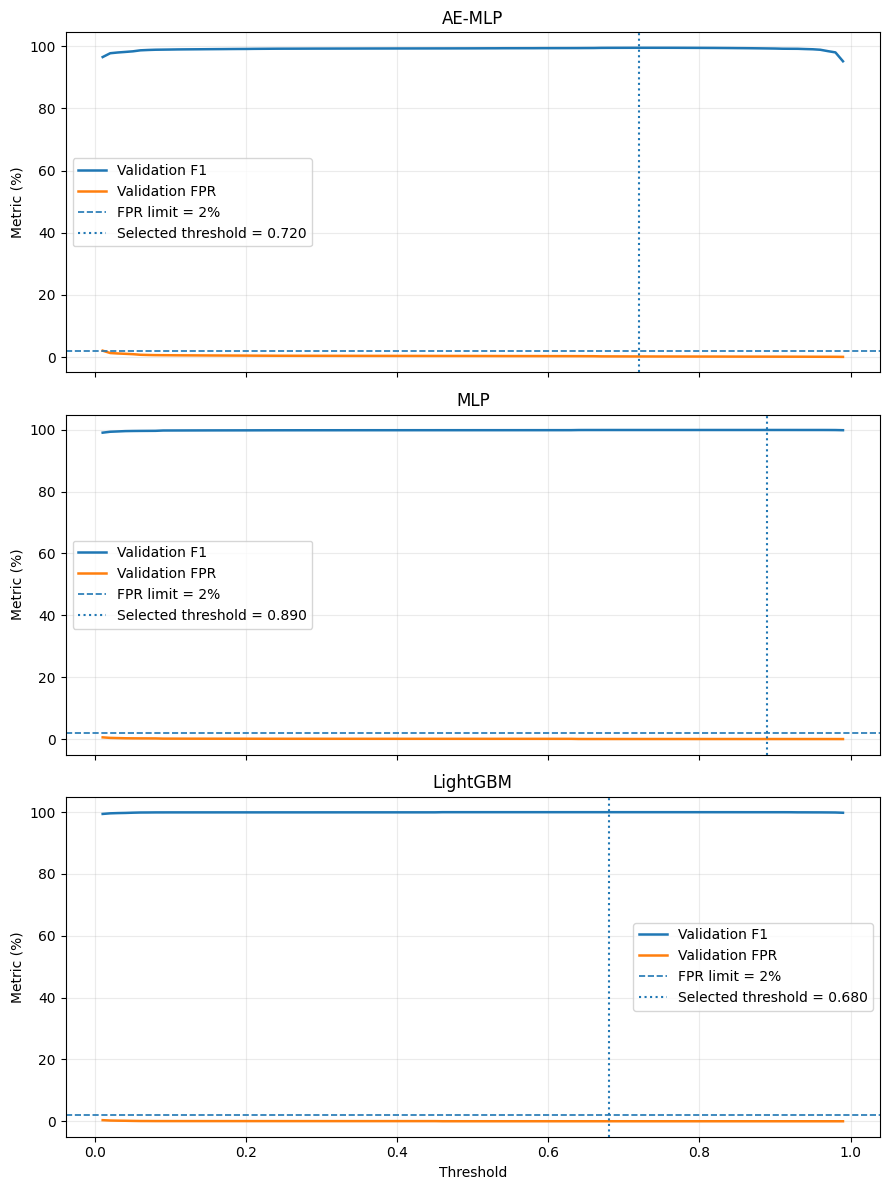

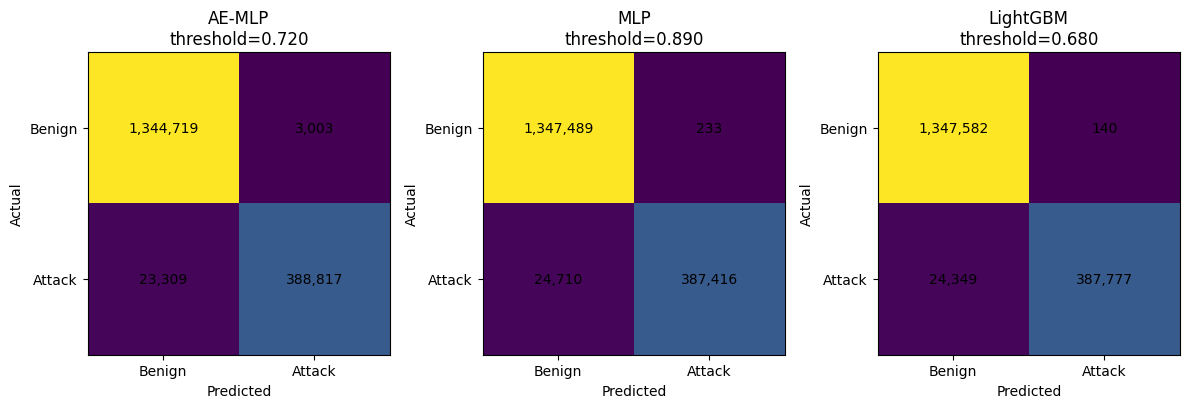

Saved figures:
/content/drive/MyDrive/CICIDS2018/threshold_validation_final_grid_0p01/fig_validation_threshold_selection.pdf
/content/drive/MyDrive/CICIDS2018/threshold_validation_final_grid_0p01/fig_comparative_confusion_validation_thresholds.pdf


In [15]:

# ============================================================
# CELL 10 — FIGURES
# ============================================================

MODEL_ORDER = ["AE-MLP", "MLP", "LightGBM"]

# 1. Validation threshold trade-off.
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(9, 12),
    sharex=True,
)

for axis, model_name in zip(axes, MODEL_ORDER):
    model_sweep = df_threshold_sweep[
        df_threshold_sweep["Model"] == model_name
    ]
    threshold = thresholds_final[model_name]

    axis.plot(
        model_sweep["Threshold"],
        model_sweep["F1"] * 100,
        label="Validation F1",
        linewidth=1.8,
    )
    axis.plot(
        model_sweep["Threshold"],
        model_sweep["FPR"] * 100,
        label="Validation FPR",
        linewidth=1.8,
    )
    axis.axhline(
        FPR_LIMIT * 100,
        linestyle="--",
        linewidth=1.2,
        label="FPR limit = 2%",
    )
    axis.axvline(
        threshold,
        linestyle=":",
        linewidth=1.5,
        label=f"Selected threshold = {threshold:.3f}",
    )

    axis.set_title(model_name)
    axis.set_ylabel("Metric (%)")
    axis.grid(alpha=0.25)
    axis.legend()

axes[-1].set_xlabel("Threshold")
fig.tight_layout()

THRESHOLD_FIG_PATH = OUTPUT_DIR / "fig_validation_threshold_selection.pdf"
fig.savefig(
    THRESHOLD_FIG_PATH,
    bbox_inches="tight",
)
plt.show()

# 2. Comparative confusion matrices.
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(12, 4),
)

for axis, model_name in zip(axes, MODEL_ORDER):
    model_rows = df_test_confusion[
        df_test_confusion["Model"] == model_name
    ]

    matrix = np.array([
        [
            model_rows[
                (model_rows["Actual"] == "Benign")
                & (model_rows["Predicted"] == "Benign")
            ]["Count"].iloc[0],
            model_rows[
                (model_rows["Actual"] == "Benign")
                & (model_rows["Predicted"] == "Attack")
            ]["Count"].iloc[0],
        ],
        [
            model_rows[
                (model_rows["Actual"] == "Attack")
                & (model_rows["Predicted"] == "Benign")
            ]["Count"].iloc[0],
            model_rows[
                (model_rows["Actual"] == "Attack")
                & (model_rows["Predicted"] == "Attack")
            ]["Count"].iloc[0],
        ],
    ])

    image = axis.imshow(matrix)

    for row in range(2):
        for column in range(2):
            axis.text(
                column,
                row,
                f"{matrix[row, column]:,}",
                ha="center",
                va="center",
            )

    axis.set_title(
        f"{model_name}\n"
        f"threshold={thresholds_final[model_name]:.3f}"
    )
    axis.set_xticks([0, 1], ["Benign", "Attack"])
    axis.set_yticks([0, 1], ["Benign", "Attack"])
    axis.set_xlabel("Predicted")
    axis.set_ylabel("Actual")

fig.tight_layout()

CONFUSION_FIG_PATH = OUTPUT_DIR / "fig_comparative_confusion_validation_thresholds.pdf"
fig.savefig(
    CONFUSION_FIG_PATH,
    bbox_inches="tight",
)
plt.show()

print("Saved figures:")
print(THRESHOLD_FIG_PATH)
print(CONFUSION_FIG_PATH)


In [16]:

# ============================================================
# CELL 11 — PAPER-READY TABLES DAN INTEGRITY REPORT
# ============================================================

paper_metrics = df_test_binary.copy()

for column in [
    "Accuracy",
    "Precision attack",
    "Recall attack",
    "F1 attack",
    "FPR",
    "PR-AUC",
    "ROC-AUC",
]:
    paper_metrics[column] = paper_metrics[column] * 100

paper_metrics = paper_metrics[
    [
        "Model",
        "Frozen threshold",
        "Accuracy",
        "Precision attack",
        "Recall attack",
        "F1 attack",
        "FPR",
        "PR-AUC",
        "ROC-AUC",
        "TN",
        "FP",
        "FN",
        "TP",
    ]
]

PAPER_METRICS_PATH = OUTPUT_DIR / "paper_test_metrics_percent.csv"
paper_metrics.to_csv(PAPER_METRICS_PATH, index=False)

paper_per_class = df_test_per_class.copy()
paper_per_class["Correct-classification rate (%)"] = (
    paper_per_class["Correct-classification rate"] * 100
)

paper_per_class = paper_per_class[
    [
        "Model",
        "Traffic class",
        "Binary target",
        "Support",
        "Correctly classified",
        "Correct-classification rate (%)",
        "Held-out zero-day",
        "Frozen threshold",
    ]
]

PAPER_PER_CLASS_PATH = OUTPUT_DIR / "paper_per_class_detection_percent.csv"
paper_per_class.to_csv(PAPER_PER_CLASS_PATH, index=False)

integrity_report = {
    "models_retrained": False,
    "models_refitted": False,
    "test_data_used_for_threshold_selection": False,
    "validation_infiltration_removed": True,
    "removed_validation_infiltration_rows": removed_infiltration,
    "threshold_selection_rows": int(len(y_val)),
    "threshold_grid": {
        "start": 0.01,
        "end": 0.99,
        "step": 0.01,
    },
    "selection_rule": {
        "maximum_validation_f1": True,
        "validation_fpr_limit_fraction": FPR_LIMIT,
        "tie_break_1": "minimum validation FPR",
        "tie_break_2": "maximum threshold",
    },
    "test_evaluated_after_threshold_freezing": True,
    "prediction_rule": "probability > threshold",
    "thresholds": thresholds_final,
    "test_support": int(len(y_test)),
    "test_infiltration_support": int(
        (label_test == ZERO_DAY_LABEL).sum()
    ),
    "artifacts": {
        "selected_thresholds": str(SELECTED_PATH),
        "test_metrics": str(TEST_BINARY_PATH),
        "per_class_detection": str(TEST_PER_CLASS_PATH),
        "confusion_counts": str(TEST_CONFUSION_PATH),
    },
}

INTEGRITY_PATH = OUTPUT_DIR / "threshold_evaluation_integrity_report.json"

with open(
    INTEGRITY_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        integrity_report,
        file,
        indent=2,
    )

print("PAPER-READY TEST METRICS (%)")
display(paper_metrics)

print("\nPAPER-READY HELD-OUT INFILTRATION")
display(
    paper_per_class[
        paper_per_class["Held-out zero-day"]
    ]
)

print("\nINTEGRITY REPORT")
print(json.dumps(integrity_report, indent=2))

print("\nSaved:")
print(PAPER_METRICS_PATH)
print(PAPER_PER_CLASS_PATH)
print(INTEGRITY_PATH)


PAPER-READY TEST METRICS (%)


,Model,Frozen threshold,Accuracy,Precision attack,Recall attack,F1 attack,FPR,PR-AUC,ROC-AUC,TN,FP,FN,TP
0,AE-MLP,0.72,98.504871,99.233577,94.344205,96.727143,0.222820,97.432729,97.880473,1344719,3003,23309,388817
1,MLP,0.89,98.582662,99.939894,94.004261,96.881248,0.017288,97.536421,98.150279,1347489,233,24710,387416
2,LightGBM,0.68,98.608459,99.963910,94.091855,96.939040,0.010388,97.220287,97.836675,1347582,140,24349,387777



PAPER-READY HELD-OUT INFILTRATION


,Model,Traffic class,Binary target,Support,Correctly classified,Correct-classification rate (%),Held-out zero-day,Frozen threshold
12,AE-MLP,Infiltration,Attack,24180,1967,8.134822,True,0.72
27,MLP,Infiltration,Attack,24180,31,0.128205,True,0.89
42,LightGBM,Infiltration,Attack,24180,45,0.186104,True,0.68



INTEGRITY REPORT
{
  "models_retrained": false,
  "models_refitted": false,
  "test_data_used_for_threshold_selection": false,
  "validation_infiltration_removed": true,
  "removed_validation_infiltration_rows": 24156,
  "threshold_selection_rows": 1735731,
  "threshold_grid": {
    "start": 0.01,
    "end": 0.99,
    "step": 0.01
  },
  "selection_rule": {
    "maximum_validation_f1": true,
    "validation_fpr_limit_fraction": 0.02,
    "tie_break_1": "minimum validation FPR",
    "tie_break_2": "maximum threshold"
  },
  "test_evaluated_after_threshold_freezing": true,
  "prediction_rule": "probability > threshold",
  "thresholds": {
    "AE-MLP": 0.72,
    "MLP": 0.89,
    "LightGBM": 0.68
  },
  "test_support": 1759848,
  "test_infiltration_support": 24180,
  "artifacts": {
    "selected_thresholds": "/content/drive/MyDrive/CICIDS2018/threshold_validation_final_grid_0p01/selected_thresholds_validation.csv",
    "test_metrics": "/content/drive/MyDrive/CICIDS2018/threshold_validatio

In [17]:

# ============================================================
# CELL 12 — EXPORT COMPLETE EVIDENCE ZIP
# ============================================================

ZIP_PATH = OUTPUT_DIR / "ICICoS2026_Step1_Threshold_Validation_Evidence.zip"

evidence_files = [
    VALIDATION_PROB_PATH,
    SWEEP_PATH,
    SELECTED_PATH,
    THRESHOLD_JSON_PATH,
    TEST_BINARY_PATH,
    TEST_CONFUSION_PATH,
    TEST_PER_CLASS_PATH,
    TEST_PROB_PATH,
    THRESHOLD_FIG_PATH,
    CONFUSION_FIG_PATH,
    PAPER_METRICS_PATH,
    PAPER_PER_CLASS_PATH,
    INTEGRITY_PATH,
]

evidence_files.extend(
    OUTPUT_DIR.glob("threshold_*_validation_final.pkl")
)

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:
    for file_path in evidence_files:
        file_path = Path(file_path)

        if file_path.exists():
            archive.write(
                file_path,
                arcname=file_path.name,
            )

print("Complete evidence ZIP:")
print(ZIP_PATH)

try:
    from google.colab import files
    files.download(str(ZIP_PATH))
    print("Download triggered.")
except Exception as exc:
    print("Automatic download skipped:", exc)


Complete evidence ZIP:
/content/drive/MyDrive/CICIDS2018/threshold_validation_final_grid_0p01/ICICoS2026_Step1_Threshold_Validation_Evidence.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered.



## Notebook selesai


- `selected_thresholds_validation.csv`
- `paper_test_metrics_percent.csv`
- `paper_per_class_detection_percent.csv`
- `test_confusion_counts_frozen_validation_thresholds.csv`
- `fig_comparative_confusion_validation_thresholds.pdf`
- `threshold_evaluation_integrity_report.json`
